In [5]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 4.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]


In [6]:
import tensorflow as tf
import random
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.model_selection import train_test_split
import cv2

In [7]:
import os

BASE = "Wound_Dataset"

data_class = os.listdir(BASE)
print(f"Available classes in dataset: {data_class}")
            

Available classes in dataset: ['Abrasions', '.DS_Store', 'Diabetic Wounds', 'Surgical Wounds', 'Bruises', 'Cut', 'Venous Wounds', 'Normal', 'Pressure Wounds', 'Laseration', 'Burns']


In [8]:
path_file = []
label = []

for nama_kelas in data_class:
    class_path = os.path.join(BASE, nama_kelas)
    if os.path.isdir(class_path):
        for file_name in os.listdir(class_path):
            path_file.append(os.path.join(class_path, file_name))
            label.append(nama_kelas)

train_files, test_files, train_labels, test_labels = train_test_split(path_file, label, test_size=0.3, random_state=42)

print(f'Number of train dataset: {len(train_files)}')
print(f'Number of test dataset: {len(test_files)}')

Number of train dataset: 2058
Number of test dataset: 882


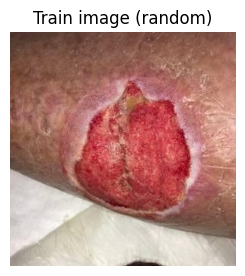

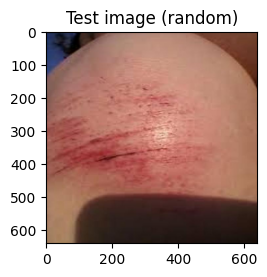

In [9]:
plt.subplot(1,2,1)
plt.imshow(mpimg.imread(random.choice(train_files)))
plt.title("Train image (random)")
plt.axis("off")
plt.show

plt.figure(figsize=[6,6])
plt.subplot(1,2,1)
plt.imshow(mpimg.imread(random.choice(test_files)))
plt.title("Test image (random)")
plt.show()

In [10]:
from tensorflow.keras.applications.resnet50 import preprocess_input

def normalize_image(image):    
    if image.ndim == 2:                   
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    elif image.shape[2] == 1:                
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    else:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (299, 299))
    image = image.astype("float32")
    return preprocess_input(image)

In [11]:
def load_dataset(path):
    img_list = []
    label_list = []

    for category in os.listdir(path):
        category_path = os.path.join(path, category)

        if not os.path.isdir(category_path):
            continue

        for fname in os.listdir(category_path):
            fpath = os.path.join(category_path, fname)
            img = cv2.imread(fpath)

            if img is None:
                continue

            processed = normalize_image(img)
            img_list.append(processed)
            label_list.append(category)

    return np.array(img_list), np.array(label_list)


In [ ]:
from keras.applications.resnet50 import preprocess_input
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

X_data, y_label = load_dataset(BASE)

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_label)
y_onehot = to_categorical(y_encoded)

X_train, X_val, y_train, y_val = train_test_split(
    X_data, y_onehot, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)

Train shape: (2352, 299, 299, 3)
Val shape: (588, 299, 299, 3)


In [13]:
augmenter = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.18,
    height_shift_range=0.18,
    brightness_range=(0.75, 1.25),
    zoom_range=0.25,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

augmenter.fit(X_train)


Showing 9 images from the augmented dataset:


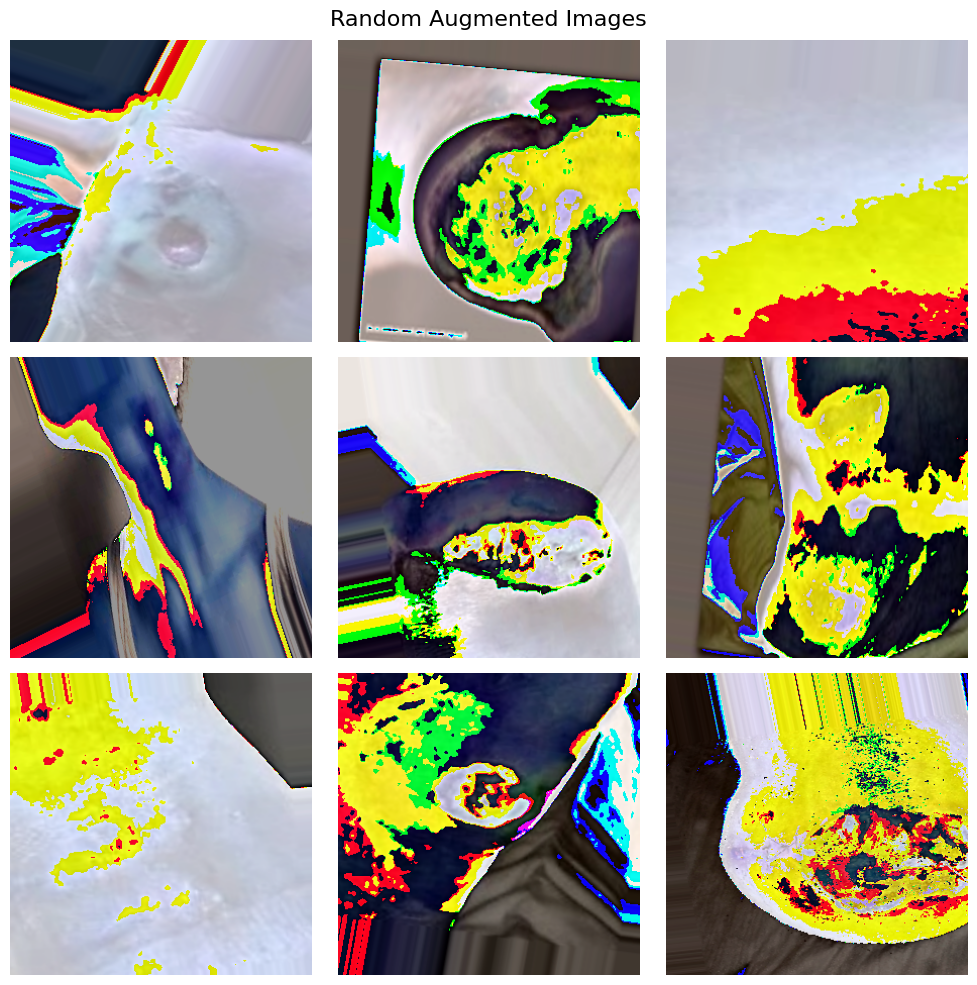

In [14]:
import matplotlib.pyplot as plt
import numpy as np

print("Showing 9 images from the augmented dataset:")

plt.figure(figsize=(10, 10))

for i in range(9):
    random_index = np.random.randint(0, X_train.shape[0])
    img = X_train[random_index]
    img_batch = np.expand_dims(img, axis=0)
    aug_iterator = augmenter.flow(img_batch, batch_size=1)
    augmented_img_batch = next(aug_iterator)
    augmented_img = augmented_img_batch[0].astype('uint8')
    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_img)
    plt.axis('off')

plt.suptitle("Random Augmented Images", fontsize=16)
plt.tight_layout()
plt.show()

In [28]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import BatchNormalization 
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base = ResNet50(
    weights='imagenet',
    include_top = False,
    input_shape = (299, 299, 3)  
)
for lyr in base.layers[:-12]:
    lyr.trainable = False


class MyBatchNorm(BatchNormalization):
    def get_config(self):
        config = super().get_config()
        config['axis'] = -1
        return config

In [22]:
import tensorflow as tf
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    base,
    GlobalAveragePooling2D(),
    MyBatchNorm(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

y_train_int = np.argmax(y_train, axis=1)

In [17]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
]

In [17]:
from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),  
    y = y_train_int  
)
weight_dict = dict(enumerate(weights))

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    class_weight=weight_dict,
    callbacks=callbacks
)


Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 499s 7s/step - accuracy: 0.3237 - loss: 2.1422 - val_accuracy: 0.7228 - val_loss: 0.9204 - learning_rate: 1.0000e-04
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 472s 6s/step - accuracy: 0.7756 - loss: 0.5133 - val_accuracy: 0.8435 - val_loss: 0.5507 - learning_rate: 1.0000e-04
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 458s 6s/step - accuracy: 0.8921 - loss: 0.2353 - val_accuracy: 0.8997 - val_loss: 0.3545 - learning_rate: 1.0000e-04
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 476s 6s/step - accuracy: 0.9316 - loss: 0.1553 - val_accuracy: 0.9269 - val_loss: 0.2653 - learning_rate: 1.0000e-04
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 476s 6s/step - accuracy: 0.9606 - loss: 0.0929 - val_accuracy: 0.9439 - val_loss: 0.1976 - learning_rate: 1.0000e-04
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 437s 6s/step - accuracy: 0.9863 - loss: 0.0497 - val_accuracy: 0.9473 - val_loss: 0.1669 - learning_rate: 1.0000e-04
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 470s 6s/step - accuracy: 0.9871 

In [18]:
model.save("ResNet50_new.h5")

In [19]:
model.save_weights("ResNet50_new.weights.h5")

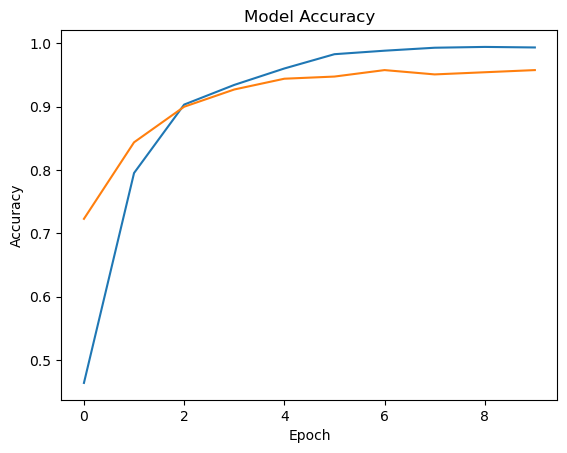

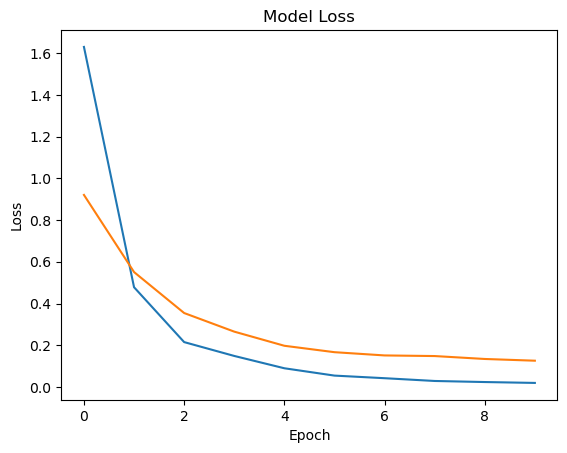

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 95s 5s/step

Laporan Klasifikasi:

                 precision    recall  f1-score   support

      Abrasions       1.00      0.93      0.97        30
        Bruises       0.98      1.00      0.99        50
          Burns       1.00      0.91      0.95        23
            Cut       0.91      1.00      0.95        20
Diabetic Wounds       0.94      0.91      0.93       111
     Laseration       1.00      1.00      1.00        29
         Normal       0.97      1.00      0.99        34
Pressure Wounds       0.96      0.96      0.96       128
Surgical Wounds       0.93      0.97      0.95        73
  Venous Wounds       0.95      0.96      0.95        90

       accuracy                           0.96       588
      macro avg       0.96      0.96      0.96       588
   weighted avg       0.96      0.96      0.96       588


Confusion Matrix:



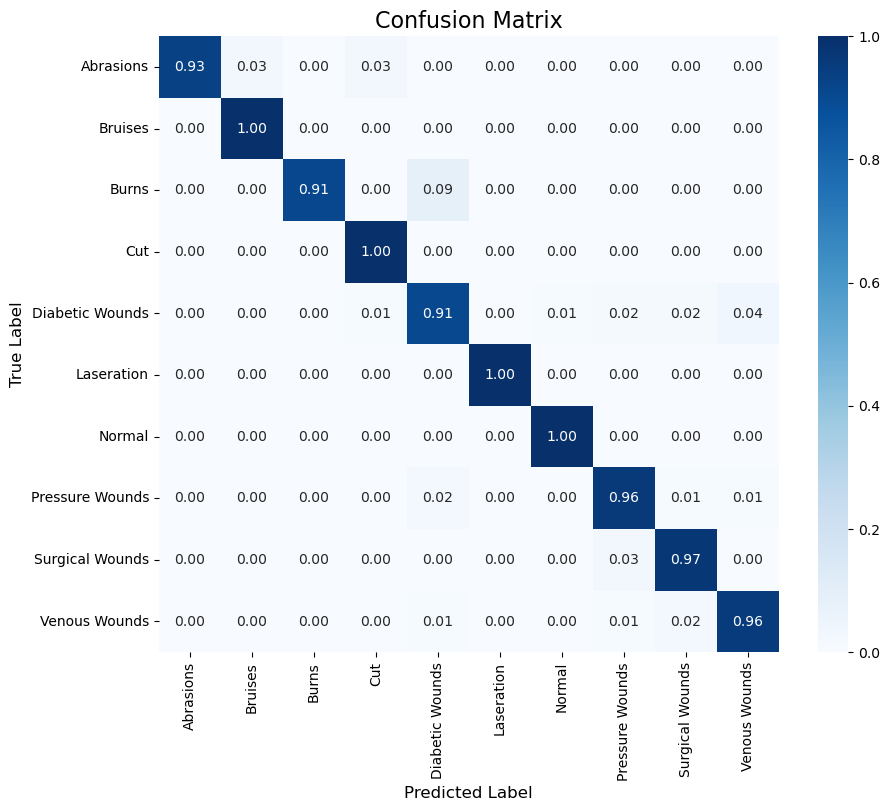

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

Y_pred = model.predict(X_val)
y_pred = np.argmax(Y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)
class_names = encoder.classes_

print("\Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\nConfusion Matrix:\n")
cm = confusion_matrix(y_true, y_pred)
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import json

try:
    from lime import lime_image
    from skimage.segmentation import mark_boundaries
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lime", "scikit-image"])
    from lime import lime_image
    from skimage.segmentation import mark_boundaries

LABEL_MAP = {
    'Abrasions': 'Luka Abrasi',
    'Bruises': 'Luka Memar',
    'Burns': 'Luka Bakar',
    'Cut': 'Luka Goresan',
    'Diabetic Wounds': 'Luka Diabetes',
    'Laseration': 'Luka Laser',
    'Normal': 'Kulit Normal',
    'Pressure Wounds' : 'Luka Tekan',
    'Surgical Wounds' : 'Luka Bedah',
    'Venous Wounds' : 'Luka Vena'


}

RECOMMENDATION_MAP = {
    'Luka Abrasi': 
        "An abrasion occurs due to friction that removes the uppermost layer of the skin. "
        "Recommendation: Gently clean the wound, apply an antiseptic, and cover it with sterile gauze. "
        "If signs of infection appear, consult a physician immediately.",

    'Luka Memar': 
        "A contusion occurs as a result of an impact that damages the small blood vessels beneath the skin. "
        "Recommendation: Apply a cold compress for 10–15 minutes to reduce swelling and pain. "
        "If the contusion is exceptionally large or fails to improve, seek medical attention.",

    'Luka Bakar': 
        "A burn can be caused by heat, electricity, chemicals, or radiation. "
        "Recommendation: Cool the affected area under running water for 10–20 minutes, refrain from applying toothpaste or ointments, "
        "and cover the wound with sterile gauze. If the burn is moderate to severe, seek medical assistance immediately.",

    'Luka Goresan': 
        "A scratch is typically shallow but may lead to infection if left untreated. "
        "Recommendation: Clean the wound, apply an antiseptic, and cover it if necessary. "
        "If the wound is deep or the bleeding does not cease, contact a healthcare professional.",

    'Luka Diabetes': 
        "A diabetic ulcer requires intensive care due to a high risk of infection. "
        "Recommendation: Consult a physician promptly for wound care, maintain strict blood sugar control, "
        "and avoid placing excessive pressure on the affected area.",

    'Luka Laser': 
        "A laceration is a tear in the skin that frequently requires medical intervention. "
        "Recommendation: Halt the bleeding by applying gentle pressure, clean the area with an antiseptic, "
        "and consult a physician to determine if sutures are necessary.",

    'Kulit Normal': 
        "No wounds or abnormalities are detected. "
        "Recommendation: Maintain proper skin hygiene and moisture to prevent dermatological issues.",

    'Luka Tekan': 
        "A pressure ulcer (bedsore) occurs as a result of prolonged pressure on the skin. "
        "Recommendation: Alleviate pressure by frequently changing positions, maintain skin hygiene, and "
        "consult a healthcare professional immediately for further treatment.",

    'Luka Bedah': 
        "A surgical wound is a post-operative incision that requires proper care to prevent infection. "
        "Recommendation: Adhere strictly to the physician's instructions, keep the wound clean and dry, "
        "and seek medical attention promptly if redness, pus, or fever develops.",

    'Luka Vena': 
        "A venous ulcer is typically associated with circulatory disorders in the leg veins. "
        "Recommendation: Consult a vascular specialist immediately, utilize compression bandages if advised, "
        "and avoid prolonged periods of standing."
}


In [ ]:
model_path = 'ResNet50_new.h5'

class MyBatchNorm(tf.keras.layers.BatchNormalization):
    def get_config(self):
        config = super().get_config()
        config["axis"] = -1
        return config

try:
    model = tf.keras.models.load_model(
        model_path,
        custom_objects={"MyBatchNorm": MyBatchNorm}
    )
    print("Model loaded successfully.")
except Exception as e:
    print("Error while loading the model:", e)


class_names = list(LABEL_MAP.keys())  

rand_idx = np.random.randint(0, len(X_val))
img_array = X_val[rand_idx]         
true_label_idx = np.argmax(y_val[rand_idx])
true_label_full = LABEL_MAP.get(class_names[true_label_idx], "Unknown")

img_preprocessed = np.expand_dims(img_array, axis=0)


predictions = model.predict(img_preprocessed)[0]
top_5 = np.argsort(predictions)[-5:][::-1]

top_5_predictions = [
    {
        "kelas": LABEL_MAP.get(class_names[i], "NA"),
        "probabilitas": f"{predictions[i]:.2%}"
    }
    for i in top_5
]


top_label_full = LABEL_MAP.get(class_names[top_5[0]], "Unknown")
binary_classification = "Luka Diabetes" if top_label_full == "Diabetic Wounds" else "Not Diabetic Wound"


explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(
    img_array.astype("double"),
    model.predict,
    top_labels=5,
    hide_color=0,
    num_samples=1000
)

temp, mask = explanation.get_image_and_mask(
    top_5[0], 
    positive_only=True, 
    num_features=5, 
    hide_rest=False
)


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_array)
plt.title(f"Real Image (Label: {true_label_full})")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(temp / 255.)
plt.imshow(mask, cmap="jet", alpha=0.5)
plt.title("LIME Heatmap")
plt.axis("off")

plt.show()

top_predicted_label_short = class_names[top_5[0]]
top_predicted_label_full = LABEL_MAP.get(top_predicted_label_short, "Unknown")


rekomendasi_teks = RECOMMENDATION_MAP.get(top_predicted_label_full, "No recommendation available.")

output_data = {
    "image_file": f"Index in validation dataset: {rand_idx}",
    "real_class": true_label_full,
    "diabetic_classification": binary_classification,
    "top_prediction": top_5_predictions[0],
    "top_5_predictions": top_5_predictions,
    "general_recommendation": rekomendasi_teks,
    "medical_disclaimer": (
    "IMPORTANT: This result is the output of a computer program and "
    "NOT a medical diagnosis. For proper treatment and management, "
    "please always consult with a qualified healthcare professional."
    )
}

with open('prediction_results.json', 'w') as f:
    json.dump(output_data, f, indent=4, ensure_ascii=False)

print("\XAI analysis completed and file 'prediction_results.json' has been created.")
